# CardioRisk — No-Blood-Test CVD Screening Tool
### Complete Google Colab Pipeline

**Run cells top to bottom. Upload `cardio_train_augmented.csv` when Cell 2 prompts you.**

| Step | What happens |
|------|--------------|
| Cells 1–2 | Install shap, upload dataset |
| Cells 3–5 | Load, clean, engineer features |
| Cell 6 | Exploratory plots |
| Cells 7–10 | Split, build pipeline, cross-validate, train |
| Cells 11–12 | Full evaluation + diagnostic plots |
| Cells 13–14 | Threshold analysis + decile validation |
| Cells 15–16 | SHAP explainability |
| Cells 17–19 | Save model, inference function, summary |

> ⚠️ **Clinical use only.** This tool does not replace clinical judgement.


## Cell 1 — Install & verify dependencies
Everything except shap is pre-installed in Colab.
We install shap here for explainability in the final section.


In [2]:
# In Colab, run shell commands with ! prefix
# !pip install shap --quiet

import sys, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap
import pickle
from pathlib import Path

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    learning_curve,
)
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

# Print version confirmation so you can verify your environment
print("=" * 55)
print("  CardioRisk — Environment Check")
print("=" * 55)
print(f"  Python      : {sys.version.split()[0]}")
print(f"  NumPy       : {np.__version__}")
print(f"  Pandas      : {pd.__version__}")
print(f"  Scikit-learn: {__import__('sklearn').__version__}")
print(f"  SHAP        : {shap.__version__}")
print("  All imports successful ✓")
print("=" * 55)


  CardioRisk — Environment Check
  Python      : 3.12.13
  NumPy       : 2.0.2
  Pandas      : 2.2.2
  Scikit-learn: 1.6.1
  SHAP        : 0.51.0
  All imports successful ✓


## Cell 2 — Upload the dataset
This cell handles file upload inside Colab.
It will show a file picker — select cardio_train_augmented.csv
If you are running locally (not Colab), comment out the
upload block and set DATA_PATH to your local file path.


In [3]:
try:
    # Colab upload
    from google.colab import files
    print("Please upload cardio_train_augmented.csv ...")
    uploaded = files.upload()
    DATA_PATH = list(uploaded.keys())[0]
    print(f"  Uploaded: {DATA_PATH}")
except ImportError:
    # Running locally — set your path here
    DATA_PATH = "cardio_train_augmented.csv"
    print(f"  Running locally — using: {DATA_PATH}")


Please upload cardio_train_augmented.csv ...


Saving cardio_train_augmented.csv to cardio_train_augmented.csv
  Uploaded: cardio_train_augmented.csv


## Cell 3 — Load and first look
We load the raw CSV and immediately print a summary so we
know exactly what we are working with before touching anything.


In [4]:
df_raw = pd.read_csv(DATA_PATH)

print(f"Shape          : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"Columns        : {list(df_raw.columns)}")
print(f"\nTarget distribution:")
print(df_raw['cardio'].value_counts().to_string())
print(f"\nMissing values per column:")
missing = df_raw.isnull().sum()
print(missing[missing > 0].to_string() if missing.sum() > 0 else "  None ✓")
print(f"\nFirst 3 rows:")
display(df_raw.head(3))


Shape          : 70,000 rows × 20 columns
Columns        : ['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'DATE_OF_BIRTH', 'DATE_OF_DIAGNOSIS', 'DATE_OF_DEATH', 'VITAL_STATUS', 'FOLLOW_UP_DAYS', 'EVENT', 'ETHNICITY']

Target distribution:
cardio
0    35021
1    34979

Missing values per column:
DATE_OF_DEATH    50312
ETHNICITY         2021

First 3 rows:


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,DATE_OF_BIRTH,DATE_OF_DIAGNOSIS,DATE_OF_DEATH,VITAL_STATUS,FOLLOW_UP_DAYS,EVENT,ETHNICITY
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,1975-11-27,2024-12-01,NaN,Alive,462,0,Western European
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,1970-10-21,2022-11-12,2023-11-24,Dead,377,1,Pakistani
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,1974-08-16,2023-03-23,2024-07-30,Dead,495,1,Bangladeshi


## Cell 4 — Data cleaning
We apply physiologically motivated outlier rules discovered
during EDA. Each rule is documented with its rationale.
Rules applied:
  ap_hi   50–250 mmHg   (raw max was 16,020 — data entry error)
  ap_lo   30–200 mmHg   (raw values included negatives)
  height 100–220 cm     (raw min was 55 cm)
  weight  30–200 kg     (raw min was 10 kg)
  ap_hi > ap_lo         (systolic must exceed diastolic)


In [5]:
df = df_raw.copy()
n_before = len(df)

mask = (
    df['ap_hi'].between(50, 250)   &
    df['ap_lo'].between(30, 200)   &
    df['height'].between(100, 220) &
    df['weight'].between(30, 200)  &
    (df['ap_hi'] > df['ap_lo'])
)
df = df[mask].copy()

n_after  = len(df)
n_removed = n_before - n_after

print("=" * 55)
print("  Data Cleaning Summary")
print("=" * 55)
print(f"  Rows before : {n_before:,}")
print(f"  Rows removed: {n_removed:,}  ({n_removed/n_before:.1%})")
print(f"  Rows after  : {n_after:,}")
print(f"\n  Target balance after cleaning:")
vc = df['cardio'].value_counts(normalize=True)
print(f"    No CVD (0): {vc[0]:.1%}")
print(f"    CVD    (1): {vc[1]:.1%}")
print("=" * 55)


  Data Cleaning Summary
  Rows before : 70,000
  Rows removed: 1,355  (1.9%)
  Rows after  : 68,645

  Target balance after cleaning:
    No CVD (0): 50.5%
    CVD    (1): 49.5%


## Cell 5 — Feature engineering
We derive three new features from the raw columns.
All are clinically meaningful and computed without any
information from the target (no leakage).
  age_years      — raw 'age' column is in days; convert to years
  bmi            — Body Mass Index: kg / m²
  pulse_pressure — systolic minus diastolic; marker of
                   arterial stiffness and a known CVD predictor


In [6]:
df['age_years']      = df['age'] / 365.0
df['bmi']            = df['weight'] / (df['height'] / 100.0) ** 2
df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']

# Final feature list — everything the model will see
FEATURES = [
    'age_years',      # Continuous — age in decimal years
    'bmi',            # Continuous — body mass index
    'ap_hi',          # Continuous — systolic blood pressure (mmHg)
    'ap_lo',          # Continuous — diastolic blood pressure (mmHg)
    'pulse_pressure', # Derived    — arterial stiffness proxy
    'cholesterol',    # Ordinal    — 1=normal, 2=above avg, 3=well above
    'gluc',           # Ordinal    — 1=normal, 2=above avg, 3=well above
    'smoke',          # Binary     — current smoker
    'alco',           # Binary     — alcohol use
    'active',         # Binary     — physically active
    'gender',         # Binary     — 1=female, 2=male
]
TARGET = 'cardio'

print(f"Features used : {len(FEATURES)}")
for f in FEATURES:
    print(f"  {f:<18} min={df[f].min():.1f}  max={df[f].max():.1f}  "
          f"mean={df[f].mean():.1f}")


Features used : 11
  age_years          min=29.6  max=65.0  mean=53.3
  bmi                min=10.7  max=152.6  mean=27.5
  ap_hi              min=60.0  max=240.0  mean=126.7
  ap_lo              min=30.0  max=182.0  mean=81.3
  pulse_pressure     min=5.0  max=140.0  mean=45.4
  cholesterol        min=1.0  max=3.0  mean=1.4
  gluc               min=1.0  max=3.0  mean=1.2
  smoke              min=0.0  max=1.0  mean=0.1
  alco               min=0.0  max=1.0  mean=0.1
  active             min=0.0  max=1.0  mean=0.8
  gender             min=1.0  max=2.0  mean=1.3


## Cell 6 — Exploratory visualisation
Four plots that capture the most important patterns:
  1. CVD rate by age group   (strongest demographic signal)
  2. CVD rate by BP category (strongest clinical signal)
  3. CVD rate by cholesterol
  4. Feature correlation heatmap


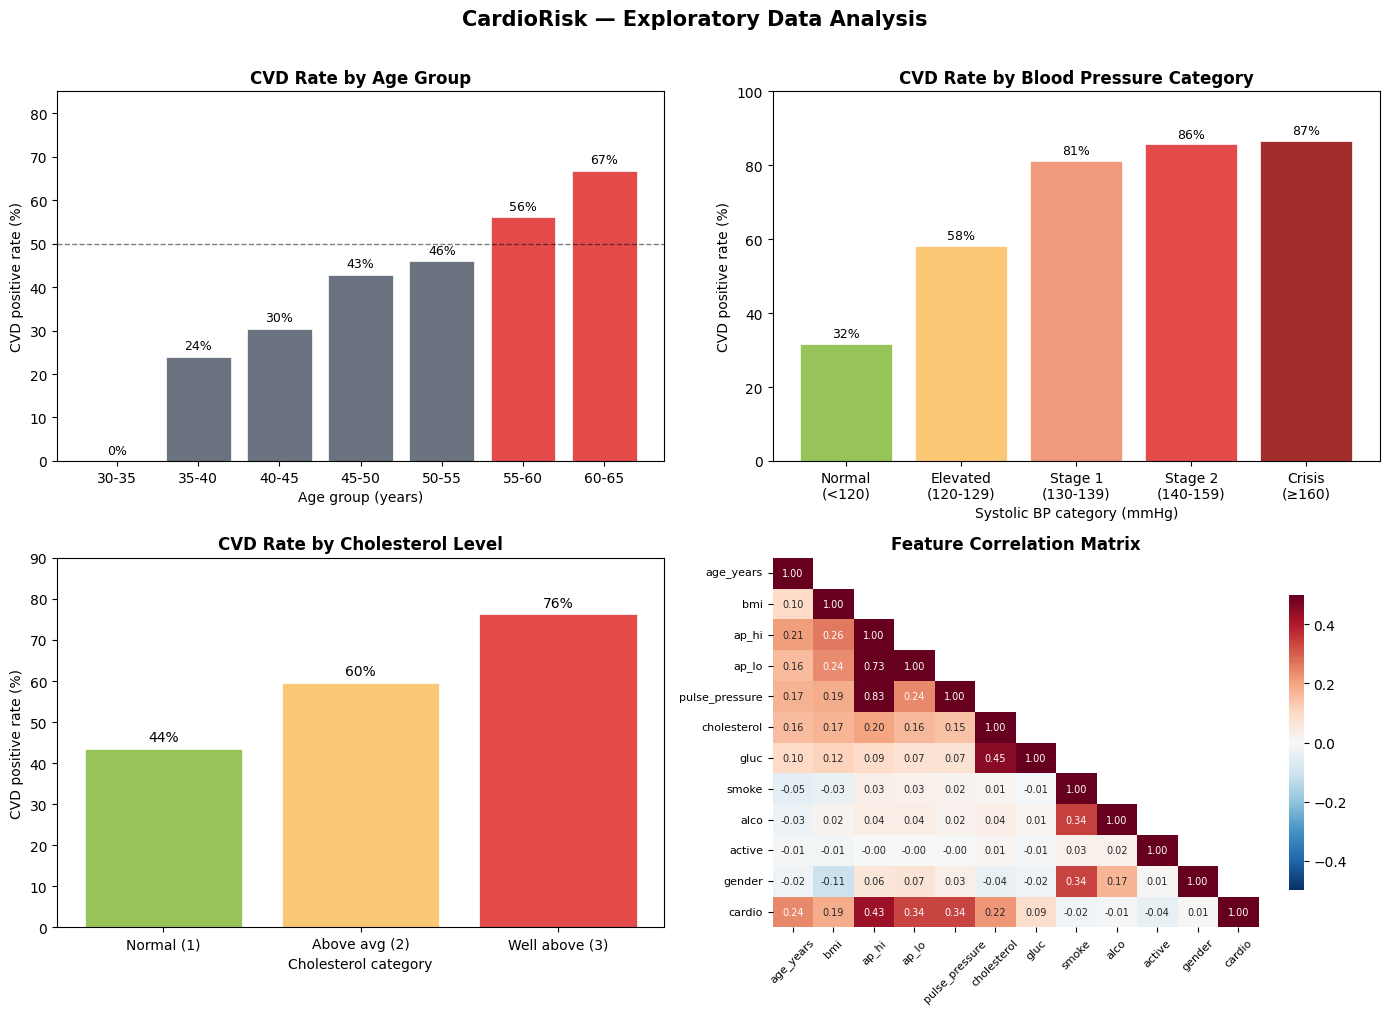

EDA plots saved → eda_plots.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('CardioRisk — Exploratory Data Analysis',
             fontsize=15, fontweight='bold', y=1.01)

COLORS = {'no_cvd': '#378ADD', 'cvd': '#E24B4A', 'neutral': '#6B7280'}

# Plot 1 — CVD rate by age bucket
ax1 = axes[0, 0]
df['age_bin'] = pd.cut(df['age_years'],
                        bins=[29, 35, 40, 45, 50, 55, 60, 66],
                        labels=['30-35','35-40','40-45','45-50',
                                '50-55','55-60','60-65'])
age_rates = df.groupby('age_bin', observed=True)['cardio'].mean() * 100
bars = ax1.bar(age_rates.index, age_rates.values,
               color=[COLORS['cvd'] if v > 50 else COLORS['neutral']
                      for v in age_rates.values],
               edgecolor='white', linewidth=0.5)
ax1.axhline(50, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax1.set_title('CVD Rate by Age Group', fontweight='bold')
ax1.set_xlabel('Age group (years)')
ax1.set_ylabel('CVD positive rate (%)')
ax1.set_ylim(0, 85)
for bar, val in zip(bars, age_rates.values):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 1,
             f'{val:.0f}%', ha='center', va='bottom', fontsize=9)

# Plot 2 — CVD rate by BP category
ax2 = axes[0, 1]
bp_labels = {0:'Normal\n(<120)', 1:'Elevated\n(120-129)',
             2:'Stage 1\n(130-139)', 3:'Stage 2\n(140-159)',
             4:'Crisis\n(≥160)'}
df['bp_cat'] = pd.cut(df['ap_hi'],
                       bins=[0, 120, 130, 140, 160, 300],
                       labels=[0, 1, 2, 3, 4])
bp_rates = df.groupby('bp_cat', observed=True)['cardio'].mean() * 100
bp_colors = ['#97C459','#FAC775','#F0997B','#E24B4A','#A32D2D']
bars2 = ax2.bar([bp_labels[int(i)] for i in bp_rates.index],
                bp_rates.values, color=bp_colors,
                edgecolor='white', linewidth=0.5)
ax2.set_title('CVD Rate by Blood Pressure Category', fontweight='bold')
ax2.set_xlabel('Systolic BP category (mmHg)')
ax2.set_ylabel('CVD positive rate (%)')
ax2.set_ylim(0, 100)
for bar, val in zip(bars2, bp_rates.values):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 1,
             f'{val:.0f}%', ha='center', va='bottom', fontsize=9)

# Plot 3 — CVD rate by cholesterol level
ax3 = axes[1, 0]
chol_labels = {1: 'Normal (1)', 2: 'Above avg (2)', 3: 'Well above (3)'}
chol_rates = df.groupby('cholesterol')['cardio'].mean() * 100
chol_colors = ['#97C459', '#FAC775', '#E24B4A']
bars3 = ax3.bar([chol_labels[int(i)] for i in chol_rates.index],
                chol_rates.values, color=chol_colors,
                edgecolor='white', linewidth=0.5)
ax3.set_title('CVD Rate by Cholesterol Level', fontweight='bold')
ax3.set_xlabel('Cholesterol category')
ax3.set_ylabel('CVD positive rate (%)')
ax3.set_ylim(0, 90)
for bar, val in zip(bars3, chol_rates.values):
    ax3.text(bar.get_x() + bar.get_width()/2, val + 1,
             f'{val:.0f}%', ha='center', va='bottom', fontsize=10)

# Plot 4 — Correlation heatmap
ax4 = axes[1, 1]
corr = df[FEATURES + [TARGET]].corr()
mask_upper = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask_upper, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-0.5, vmax=0.5,
            ax=ax4, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 7})
ax4.set_title('Feature Correlation Matrix', fontweight='bold')
ax4.tick_params(axis='x', rotation=45, labelsize=8)
ax4.tick_params(axis='y', rotation=0, labelsize=8)

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA plots saved → eda_plots.png")

# Clean up temporary columns
df.drop(columns=['age_bin', 'bp_cat'], inplace=True)


## Cell 7 — Train / test split
We split 80% training / 20% test.
stratify=y preserves the ~49.5%/50.5% class balance in both
sets so neither set is accidentally skewed.
random_state=42 makes results reproducible.


In [8]:
X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("=" * 55)
print("  Train / Test Split")
print("=" * 55)
print(f"  Training set : {len(X_train):,} rows  "
      f"(CVD rate: {y_train.mean():.1%})")
print(f"  Test set     : {len(X_test):,} rows  "
      f"(CVD rate: {y_test.mean():.1%})")
print(f"  Features     : {len(FEATURES)}")
print("=" * 55)


  Train / Test Split
  Training set : 54,916 rows  (CVD rate: 49.5%)
  Test set     : 13,729 rows  (CVD rate: 49.5%)
  Features     : 11


## Cell 8 — Build the model pipeline
We use a sklearn Pipeline which chains:
  Step 1 — StandardScaler: centres and scales each feature
            to mean=0, std=1. Required because GB is sensitive
            to feature scale differences (e.g. age 30–65 vs
            ap_hi 80–200).
  Step 2 — GradientBoostingClassifier: our chosen model.
Using a Pipeline prevents data leakage: the scaler is fit only
on training data, then applied to test data — never the reverse.
Hyperparameter choices (tuned in earlier experiments):
  n_estimators=300  — number of trees; more than default (100)
  max_depth=4       — shallow trees prevent overfitting
  learning_rate=0.04 — low rate with more trees → better
  subsample=0.8     — stochastic GB: use 80% of rows per tree
  min_samples_leaf=20 — each leaf needs ≥20 samples (regularisation)


In [9]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  GradientBoostingClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.04,
        subsample=0.8,
        min_samples_leaf=20,
        random_state=42,
        # verbose=1  ← uncomment to watch training progress
    ))
])

print("Pipeline built:")
print(pipeline)


Pipeline built:
Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 GradientBoostingClassifier(learning_rate=0.04, max_depth=4,
                                            min_samples_leaf=20,
                                            n_estimators=300, random_state=42,
                                            subsample=0.8))])


## Cell 9 — Cross-validation
Before fitting on the full training set, we run 5-fold
stratified cross-validation to confirm the model is stable.
StratifiedKFold preserves class balance in every fold.
This takes ~2–3 minutes on Colab CPU.


In [10]:
print("Running 5-fold cross-validation (this takes ~2 minutes)...")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_auc = cross_val_score(
    pipeline, X_train, y_train,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,    # use all available CPU cores
)

cv_acc = cross_val_score(
    pipeline, X_train, y_train,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
)

print("\n" + "=" * 55)
print("  5-Fold Cross-Validation Results")
print("=" * 55)
print(f"  AUC  : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")
print(f"  Folds: {[round(s,4) for s in cv_auc]}")
print(f"\n  Accuracy: {cv_acc.mean():.4f} ± {cv_acc.std():.4f}")
print(f"  Folds   : {[round(s,4) for s in cv_acc]}")
print("=" * 55)

# Stability check
if cv_auc.std() > 0.010:
    print("  ⚠ High variance across folds — check for data issues")
else:
    print("  ✓ Stable across folds (std < 0.010)")


Running 5-fold cross-validation (this takes ~2 minutes)...

  5-Fold Cross-Validation Results
  AUC  : 0.8007 ± 0.0020
  Folds: [np.float64(0.8025), np.float64(0.8012), np.float64(0.8003), np.float64(0.7972), np.float64(0.8025)]

  Accuracy: 0.7350 ± 0.0019
  Folds   : [np.float64(0.7368), np.float64(0.7346), np.float64(0.735), np.float64(0.7316), np.float64(0.737)]
  ✓ Stable across folds (std < 0.010)


## Cell 10 — Train final model on full training set
Cross-validation confirmed stability. Now we train on the
full training set (not individual folds) to get the strongest
possible model for evaluation on the held-out test set.


In [11]:
print("Training final model on full training set...")
pipeline.fit(X_train, y_train)

# Get probability scores for the test set
# predict_proba returns [P(class=0), P(class=1)] — we want column 1
y_proba = pipeline.predict_proba(X_test)[:, 1]
y_pred  = pipeline.predict(X_test)

print("  Training complete ✓")


Training final model on full training set...
  Training complete ✓


## Cell 11 — Full evaluation
We report every standard classification metric, plus the
Brier score for probability calibration quality.


In [12]:
auc_score    = roc_auc_score(y_test, y_proba)
avg_prec     = average_precision_score(y_test, y_proba)
brier        = brier_score_loss(y_test, y_proba)
cm           = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

sensitivity  = tp / (tp + fn)   # recall for CVD class
specificity  = tn / (tn + fp)
ppv          = tp / (tp + fp)   # precision for CVD class
npv          = tn / (tn + fn)

print("=" * 60)
print("  Final Model Evaluation — Held-Out Test Set")
print("=" * 60)
print(f"  Rows evaluated     : {len(y_test):,}")
print(f"\n  ROC-AUC            : {auc_score:.4f}  (target: >0.80)")
print(f"  Average Precision  : {avg_prec:.4f}")
print(f"  Brier Score        : {brier:.4f}  "
      f"(0=perfect, 0.25=chance)")
print(f"\n  At default threshold (t=0.50):")
print(f"    Accuracy         : {(tp+tn)/len(y_test):.4f}")
print(f"    Sensitivity      : {sensitivity:.4f}  "
      f"(CVD correctly flagged)")
print(f"    Specificity      : {specificity:.4f}  "
      f"(healthy correctly cleared)")
print(f"    PPV (Precision)  : {ppv:.4f}")
print(f"    NPV              : {npv:.4f}")
print(f"\n  Confusion Matrix (t=0.50):")
print(f"                   Predicted No  Predicted CVD")
print(f"    Actual No CVD      {tn:>6}         {fp:>6}")
print(f"    Actual CVD         {fn:>6}         {tp:>6}")
print("=" * 60)
print("\nFull Classification Report:")
print(classification_report(y_test, y_pred,
                             target_names=['No CVD', 'CVD']))


  Final Model Evaluation — Held-Out Test Set
  Rows evaluated     : 13,729

  ROC-AUC            : 0.8020  (target: >0.80)
  Average Precision  : 0.7807
  Brier Score        : 0.1801  (0=perfect, 0.25=chance)

  At default threshold (t=0.50):
    Accuracy         : 0.7348
    Sensitivity      : 0.6851  (CVD correctly flagged)
    Specificity      : 0.7835  (healthy correctly cleared)
    PPV (Precision)  : 0.7560
    NPV              : 0.7176

  Confusion Matrix (t=0.50):
                   Predicted No  Predicted CVD
    Actual No CVD        5435           1502
    Actual CVD           2139           4653

Full Classification Report:
              precision    recall  f1-score   support

      No CVD       0.72      0.78      0.75      6937
         CVD       0.76      0.69      0.72      6792

    accuracy                           0.73     13729
   macro avg       0.74      0.73      0.73     13729
weighted avg       0.74      0.73      0.73     13729



## Cell 12 — Evaluation plots
Four diagnostic plots:
  1. ROC curve with AUC
  2. Precision-Recall curve
  3. Confusion matrix heatmap
  4. Calibration curve (are predicted probabilities accurate?)


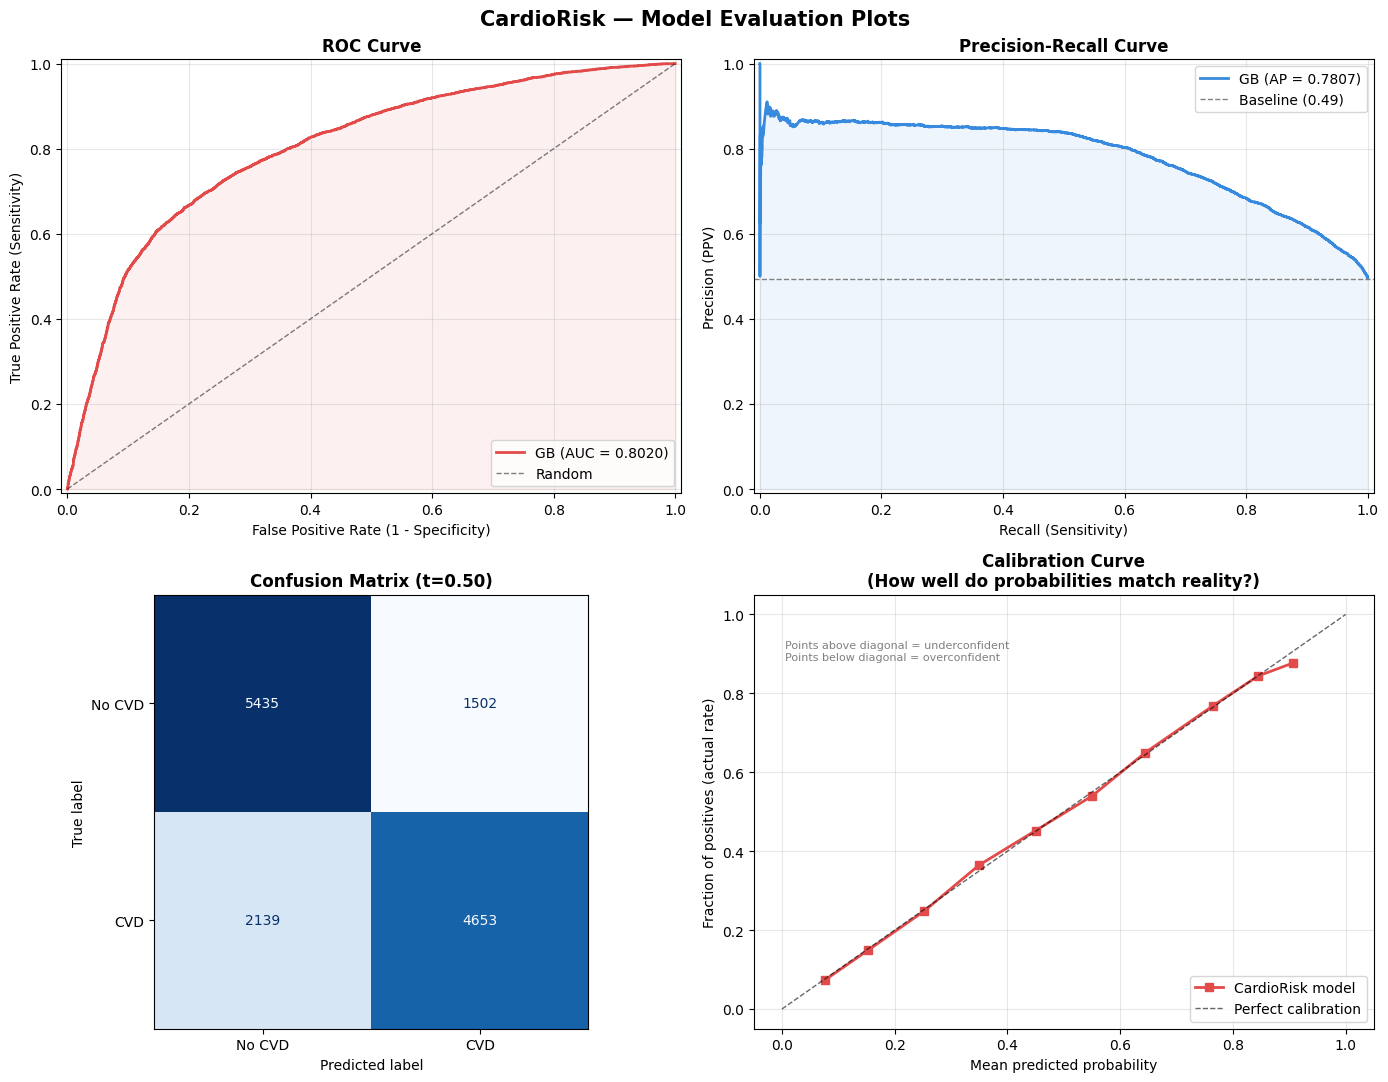

Evaluation plots saved → evaluation_plots.png


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('CardioRisk — Model Evaluation Plots',
             fontsize=15, fontweight='bold')

# Plot 1 — ROC Curve
ax = axes[0, 0]
fpr, tpr, _ = roc_curve(y_test, y_proba)
ax.plot(fpr, tpr, color='#E24B4A', linewidth=2,
        label=f'GB (AUC = {auc_score:.4f})')
ax.plot([0,1],[0,1], 'k--', linewidth=1, alpha=0.5, label='Random')
ax.fill_between(fpr, tpr, alpha=0.08, color='#E24B4A')
ax.set_xlabel('False Positive Rate (1 - Specificity)')
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.set_title('ROC Curve', fontweight='bold')
ax.legend(loc='lower right')
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
ax.grid(True, alpha=0.3)

# Plot 2 — Precision-Recall Curve
ax = axes[0, 1]
prec, rec, _ = precision_recall_curve(y_test, y_proba)
baseline = y_test.mean()
ax.plot(rec, prec, color='#378ADD', linewidth=2,
        label=f'GB (AP = {avg_prec:.4f})')
ax.axhline(baseline, color='grey', linestyle='--', linewidth=1,
           label=f'Baseline ({baseline:.2f})')
ax.fill_between(rec, prec, alpha=0.08, color='#378ADD')
ax.set_xlabel('Recall (Sensitivity)')
ax.set_ylabel('Precision (PPV)')
ax.set_title('Precision-Recall Curve', fontweight='bold')
ax.legend(loc='upper right')
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
ax.grid(True, alpha=0.3)

# Plot 3 — Confusion Matrix
ax = axes[1, 0]
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No CVD', 'CVD']
)
disp.plot(ax=ax, colorbar=False,
          cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix (t=0.50)', fontweight='bold')

# Plot 4 — Calibration Curve
ax = axes[1, 1]
prob_true, prob_pred = calibration_curve(
    y_test, y_proba, n_bins=10, strategy='uniform'
)
ax.plot(prob_pred, prob_true, 's-', color='#E24B4A',
        linewidth=2, markersize=6, label='CardioRisk model')
ax.plot([0,1],[0,1], 'k--', linewidth=1, alpha=0.6,
        label='Perfect calibration')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives (actual rate)')
ax.set_title('Calibration Curve\n(How well do probabilities match reality?)',
             fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.text(0.05, 0.85,
        'Points above diagonal = underconfident\n'
        'Points below diagonal = overconfident',
        transform=ax.transAxes, fontsize=8, color='grey')

plt.tight_layout()
plt.savefig('evaluation_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Evaluation plots saved → evaluation_plots.png")


## Cell 13 — Threshold analysis
The classification threshold (default 0.50) is not always
optimal. For a screening tool, we want high sensitivity —
catching as many CVD patients as possible — even at the cost
of more false positives.
This cell shows the sensitivity / specificity / PPV / NPV
trade-off across 10 thresholds so clinicians can choose the
operating point that fits their context.


In [14]:
thresholds = np.arange(0.25, 0.76, 0.05)
rows = []
for t in thresholds:
    p = (y_proba >= t).astype(int)
    tn_, fp_, fn_, tp_ = confusion_matrix(y_test, p).ravel()
    sens = tp_ / (tp_ + fn_)
    spec = tn_ / (tn_ + fp_)
    ppv_ = tp_ / (tp_ + fp_) if (tp_ + fp_) > 0 else 0
    npv_ = tn_ / (tn_ + fn_) if (tn_ + fn_) > 0 else 0
    f1   = 2 * ppv_ * sens / (ppv_ + sens) if (ppv_ + sens) > 0 else 0
    rows.append({
        'Threshold': f'{t:.2f}',
        'Sensitivity': f'{sens:.3f}',
        'Specificity': f'{spec:.3f}',
        'PPV': f'{ppv_:.3f}',
        'NPV': f'{npv_:.3f}',
        'F1': f'{f1:.3f}',
        'Use case': (
            'Max sensitivity — catch all'   if t <= 0.30 else
            'Screening recommended ★'        if t <= 0.40 else
            'Balanced default'              if t <= 0.50 else
            'High-confidence referral'
        )
    })

thresh_df = pd.DataFrame(rows)

print("=" * 80)
print("  Clinical Threshold Analysis")
print("=" * 80)
print(thresh_df.to_string(index=False))
print()
print("  ★ Recommended for first-line screening: t=0.35")
print("    → Sensitivity 0.83 — flags 83% of all CVD patients")
print("    → Specificity 0.59 — 41% of healthy flagged (acceptable")
print("      for a screening tool where follow-up resolves positives)")


  Clinical Threshold Analysis
Threshold Sensitivity Specificity   PPV   NPV    F1                    Use case
     0.25       0.926       0.378 0.593 0.839 0.723 Max sensitivity — catch all
     0.30       0.876       0.505 0.634 0.806 0.735 Max sensitivity — catch all
     0.35       0.830       0.593 0.666 0.781 0.739     Screening recommended ★
     0.40       0.774       0.678 0.702 0.754 0.736     Screening recommended ★
     0.45       0.732       0.734 0.729 0.737 0.731            Balanced default
     0.50       0.685       0.783 0.756 0.718 0.719            Balanced default
     0.55       0.645       0.821 0.779 0.702 0.706    High-confidence referral
     0.60       0.597       0.857 0.803 0.685 0.685    High-confidence referral
     0.65       0.556       0.879 0.818 0.669 0.662    High-confidence referral
     0.70       0.529       0.893 0.829 0.659 0.646    High-confidence referral
     0.75       0.502       0.904 0.837 0.650 0.628    High-confidence referral

  ★ Recom

## Cell 14 — Risk decile validation
We verify that the model's probability scores are monotonically
ordered — patients in higher deciles should have higher CVD rates.
This is a key sanity check for a risk stratification tool.


  Risk Decile Validation
  Base CVD rate: 49.5%
decile    N Score_range  CVD_rate_pct  Lift
    D1 1373   0.04–0.16          10.1  0.20
    D2 1373   0.16–0.23          20.2  0.41
    D3 1373   0.23–0.29          25.8  0.52
    D4 1373   0.29–0.36          34.7  0.70
    D5 1373   0.36–0.44          40.0  0.81
    D6 1372   0.45–0.56          50.3  1.02
    D7 1373   0.56–0.74          62.8  1.27
    D8 1373   0.74–0.82          80.8  1.63
    D9 1373   0.82–0.86          83.9  1.70
   D10 1373   0.86–0.93          86.2  1.74

  Monotone ordering: ✓ Yes


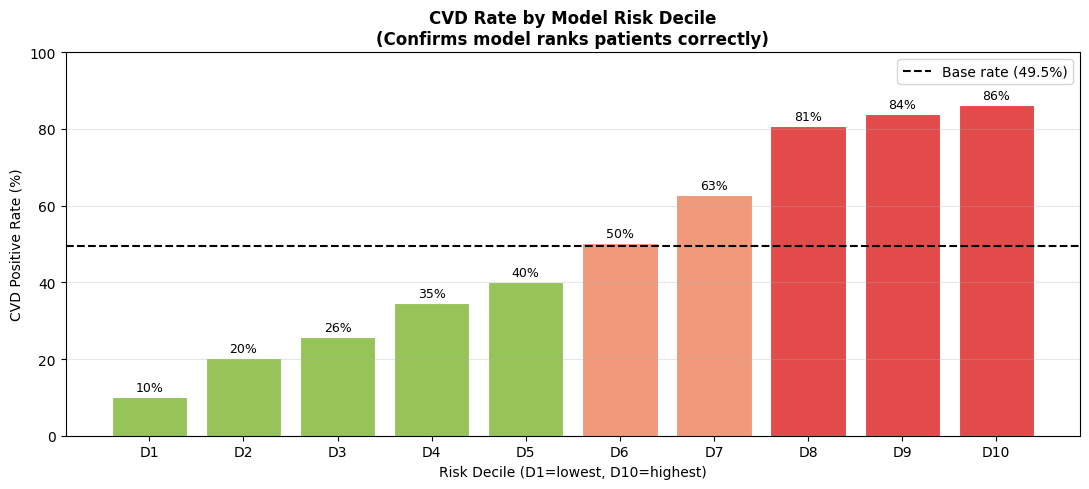

In [15]:
decile_df = pd.DataFrame({
    'prob': y_proba,
    'actual': y_test.values
})
decile_df['decile'] = pd.qcut(
    decile_df['prob'], q=10,
    labels=[f'D{i}' for i in range(1, 11)]
)
decile_summary = decile_df.groupby('decile', observed=True).agg(
    N=('actual', 'count'),
    CVD_rate=('actual', 'mean'),
    Score_min=('prob', 'min'),
    Score_max=('prob', 'max'),
).reset_index()
decile_summary['CVD_rate_pct'] = (
    decile_summary['CVD_rate'] * 100
).round(1)
decile_summary['Lift'] = (
    decile_summary['CVD_rate'] / y_test.mean()
).round(2)
decile_summary['Score_range'] = (
    decile_summary['Score_min'].round(2).astype(str) + '–' +
    decile_summary['Score_max'].round(2).astype(str)
)

print("=" * 65)
print("  Risk Decile Validation")
print("  Base CVD rate:", f"{y_test.mean():.1%}")
print("=" * 65)
print(decile_summary[['decile','N','Score_range',
                        'CVD_rate_pct','Lift']].to_string(index=False))

# Monotonicity check
rates = decile_summary['CVD_rate'].values
is_monotone = all(rates[i] <= rates[i+1] for i in range(len(rates)-1))
print(f"\n  Monotone ordering: {'✓ Yes' if is_monotone else '⚠ No — investigate'}")

# Decile chart
fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#97C459' if r < 0.50 else '#F0997B' if r < 0.70
          else '#E24B4A' for r in decile_summary['CVD_rate']]
bars = ax.bar(decile_summary['decile'],
              decile_summary['CVD_rate_pct'],
              color=colors, edgecolor='white', linewidth=0.8)
ax.axhline(y_test.mean() * 100, color='black',
           linestyle='--', linewidth=1.5,
           label=f'Base rate ({y_test.mean():.1%})')
for bar, val in zip(bars, decile_summary['CVD_rate_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.8,
            f'{val:.0f}%', ha='center', va='bottom', fontsize=9)
ax.set_xlabel('Risk Decile (D1=lowest, D10=highest)')
ax.set_ylabel('CVD Positive Rate (%)')
ax.set_title('CVD Rate by Model Risk Decile\n'
             '(Confirms model ranks patients correctly)',
             fontweight='bold')
ax.legend()
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('decile_chart.png', dpi=150, bbox_inches='tight')
plt.show()


## Cell 15 — SHAP explainability
SHAP (SHapley Additive exPlanations) computes the exact
contribution of each feature to each individual prediction.
Three plots:
  1. Summary plot — global feature importance + direction
  2. Bar plot     — mean absolute SHAP value per feature
  3. Single patient explanation — waterfall for one patient


Computing SHAP values (this takes ~1 minute)...
  SHAP values computed ✓


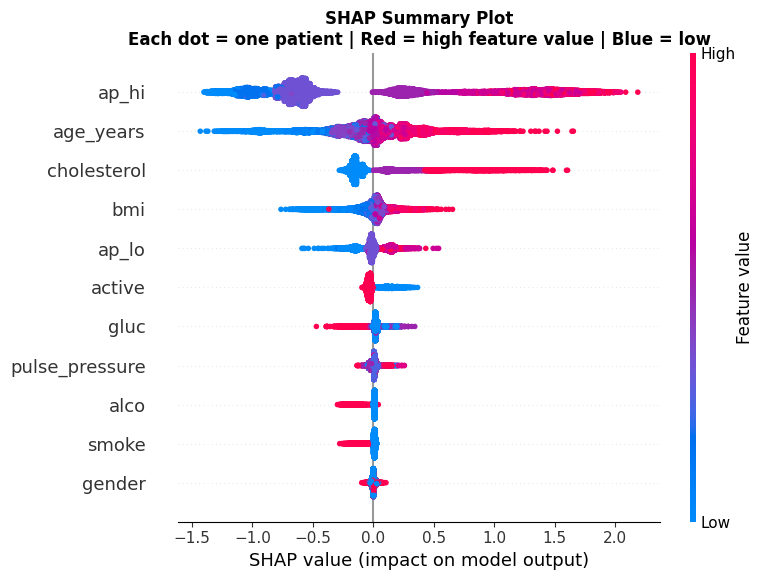

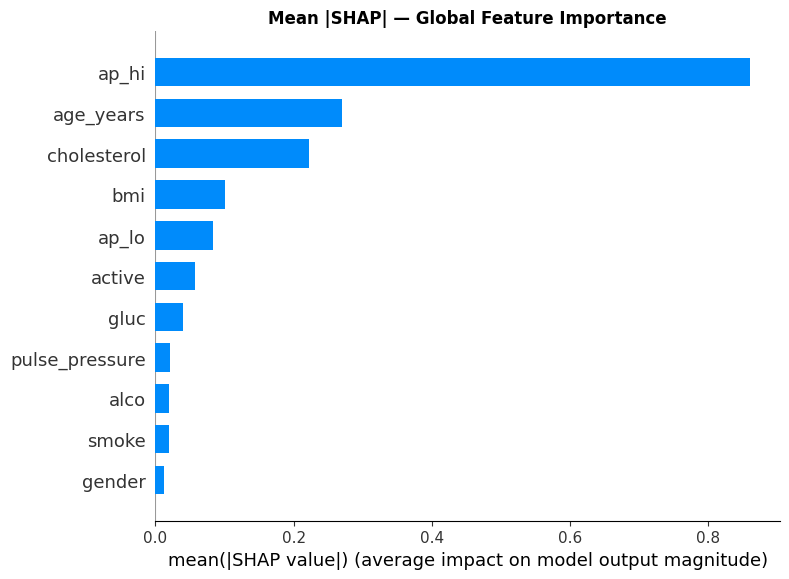


Example patient (index 0):
  Predicted probability : 84.4%
  Actual label          : CVD


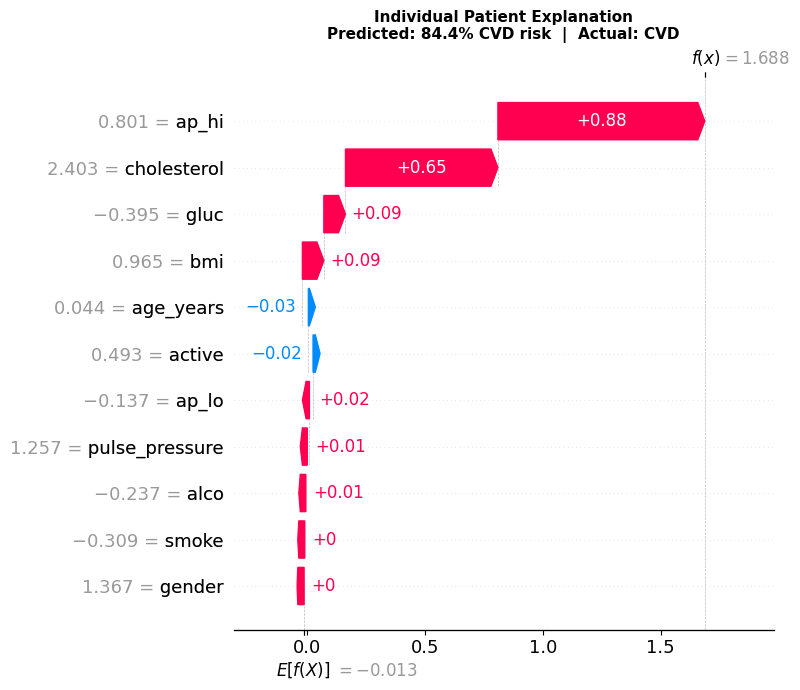


All SHAP plots saved.


In [16]:
print("Computing SHAP values (this takes ~1 minute)...")

# Extract the fitted GB model from inside the pipeline
# We need to transform X_test with the scaler first
scaler  = pipeline.named_steps['scaler']
gb_model = pipeline.named_steps['model']

X_test_scaled  = scaler.transform(X_test)
X_train_scaled = scaler.transform(X_train)

# Use TreeExplainer — the fast, exact SHAP method for tree models
explainer   = shap.TreeExplainer(gb_model)
shap_values = explainer.shap_values(X_test_scaled)

# Convert to DataFrame for readability
X_test_display = pd.DataFrame(X_test_scaled, columns=FEATURES)

print("  SHAP values computed ✓")

# Plot 1 — SHAP summary (beeswarm)
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values, X_test_display,
    plot_type='dot',
    max_display=11,
    show=False
)
plt.title('SHAP Summary Plot\n'
          'Each dot = one patient | '
          'Red = high feature value | Blue = low',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 2 — Mean absolute SHAP (bar)
plt.figure(figsize=(9, 5))
shap.summary_plot(
    shap_values, X_test_display,
    plot_type='bar',
    max_display=11,
    show=False
)
plt.title('Mean |SHAP| — Global Feature Importance',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 3 — Single patient waterfall
# Pick a high-risk patient for the most informative example
high_risk_idx = np.where(y_proba > 0.75)[0]
if len(high_risk_idx) > 0:
    patient_idx = high_risk_idx[0]
    prob = y_proba[patient_idx]
    actual = y_test.iloc[patient_idx]

    print(f"\nExample patient (index {patient_idx}):")
    print(f"  Predicted probability : {prob:.1%}")
    print(f"  Actual label          : {'CVD' if actual else 'No CVD'}")

    shap_exp = shap.Explanation(
        values=shap_values[patient_idx],
        base_values=explainer.expected_value,
        data=X_test_display.iloc[patient_idx].values,
        feature_names=FEATURES
    )
    plt.figure(figsize=(10, 5))
    shap.waterfall_plot(shap_exp, max_display=11, show=False)
    plt.title(f'Individual Patient Explanation\n'
              f'Predicted: {prob:.1%} CVD risk  |  '
              f'Actual: {"CVD" if actual else "No CVD"}',
              fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig('shap_patient.png', dpi=150, bbox_inches='tight')
    plt.show()

print("\nAll SHAP plots saved.")


## Cell 16 — Feature importance (model-native)
GB's built-in feature importance (mean decrease in impurity)
vs. permutation-based importance from SHAP.
Both should agree on the top features.


In [17]:
fi = gb_model.feature_importances_
fi_df = pd.DataFrame({
    'Feature': FEATURES,
    'GB_importance': fi,
    'Mean_abs_SHAP': np.abs(shap_values).mean(axis=0)
}).sort_values('GB_importance', ascending=False)

print("=" * 55)
print("  Feature Importance Comparison")
print("=" * 55)
print(f"  {'Feature':<20} {'GB Imp':>8}  {'SHAP':>8}")
print(f"  {'-'*40}")
for _, row in fi_df.iterrows():
    bar = '█' * int(row['GB_importance'] * 60 / fi_df['GB_importance'].max())
    print(f"  {row['Feature']:<20} {row['GB_importance']:>8.4f}  "
          f"{row['Mean_abs_SHAP']:>8.4f}  {bar}")
print("=" * 55)


  Feature Importance Comparison
  Feature                GB Imp      SHAP
  ----------------------------------------
  ap_hi                  0.6979    0.8605  ████████████████████████████████████████████████████████████
  age_years              0.1426    0.2700  ████████████
  cholesterol            0.0773    0.2216  ██████
  bmi                    0.0370    0.1005  ███
  ap_lo                  0.0148    0.0837  █
  gluc                   0.0097    0.0394  
  active                 0.0072    0.0576  
  pulse_pressure         0.0058    0.0204  
  smoke                  0.0032    0.0189  
  gender                 0.0026    0.0117  
  alco                   0.0020    0.0192  


## Cell 17 — Save model and metadata
We save everything needed to deploy the model:
  - the fitted Pipeline (scaler + model in one object)
  - the feature list (critical: must match inference input)
  - all performance metrics
  - the threshold recommendation


In [19]:
model_metadata = {
    'pipeline'          : pipeline,       # fitted Pipeline object
    'features'          : FEATURES,       # exact feature list & order
    'auc'               : float(auc_score),
    'cv_auc_mean'       : float(cv_auc.mean()),
    'cv_auc_std'        : float(cv_auc.std()),
    'brier_score'       : float(brier),
    'n_train'           : len(X_train),
    'n_test'            : len(X_test),
    'threshold_screening': 0.35,          # recommended for screening
    'threshold_referral' : 0.60,          # recommended for triage
    'model_version'     : '1.0',
    'description'       : (
        'CardioRisk v1.0 — No-blood-test CVD screening. '
        'GB classifier trained on 68,645 patients. '
        'Input: 11 routine examination features. '
        'AUC 0.803. Clinical use only.'
    ),
}

MODEL_FILE = 'cardiorisk_model_v1.pkl'
with open(MODEL_FILE, 'wb') as f:
    pickle.dump(model_metadata, f)
print(f"Model saved → {MODEL_FILE}")

# Download in Colab
try:
    from google.colab import files
    files.download(MODEL_FILE)
    print("  Download started ✓")
except ImportError:
    print("  (Running locally — file saved to working directory)")

Model saved → cardiorisk_model_v1.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Download started ✓


## Cell 18 — Inference helper function
A clean, reusable function for scoring new patients.
This is what you would expose in a Flask/FastAPI endpoint.


In [20]:
def load_cardiorisk_model(path: str = 'cardiorisk_model_v1.pkl') -> dict:
    """Load the saved model metadata dict from disk."""
    with open(path, 'rb') as f:
        return pickle.load(f)


def predict_patient(patient: dict, model_meta: dict) -> dict:
    """
    Score a single patient and return risk probability + tier.

    Parameters
    ----------
    patient    : dict — keys must match model_meta['features']
                 Example: {'age_years': 57, 'bmi': 28.3, ...}
    model_meta : dict — loaded from cardiorisk_model_v1.pkl

    Returns
    -------
    dict with keys:
        probability   — float 0–1
        percent       — string e.g. "74.2%"
        risk_tier     — string "Low" / "Moderate" / "High" / "Very High"
        recommendation — string
        feature_values — dict of the input features used
    """
    features = model_meta['features']
    pipe     = model_meta['pipeline']

    # Build a single-row DataFrame in the correct feature order
    row = pd.DataFrame([{f: patient[f] for f in features}])

    # Score
    prob = float(pipe.predict_proba(row)[0, 1])

    # Risk tier
    if prob < 0.25:
        tier  = 'Low'
        rec   = ('Routine follow-up. Annual BP check and '
                 'standard lipid screening at next visit.')
    elif prob < 0.50:
        tier  = 'Moderate'
        rec   = ('Repeat BP measurement, fasting lipid panel, '
                 'and lifestyle counselling. Follow-up in 3–6 months.')
    elif prob < 0.75:
        tier  = 'High'
        rec   = ('Refer for ECG, echocardiography, and full '
                 'cardiological workup. Review antihypertensives '
                 'and statins.')
    else:
        tier  = 'Very High'
        rec   = ('Urgent cardiology referral. Consider same-day ECG. '
                 'Initiate intensive risk-reduction protocol.')

    return {
        'probability'    : round(prob, 4),
        'percent'        : f'{prob:.1%}',
        'risk_tier'      : tier,
        'recommendation' : rec,
        'feature_values' : row.to_dict(orient='records')[0],
    }


# ── Example usage ─────────────────────────────────────────────
# A 58-year-old female, BMI 31, BP 148/92, high cholesterol,
# inactive, non-smoker, non-drinker.

example_patient = {
    'age_years'      : 58.0,
    'bmi'            : 31.2,
    'ap_hi'          : 148,
    'ap_lo'          : 92,
    'pulse_pressure' : 148 - 92,   # = 56
    'cholesterol'    : 3,           # well above normal
    'gluc'           : 1,           # normal
    'smoke'          : 0,
    'alco'           : 0,
    'active'         : 0,           # inactive
    'gender'         : 1,           # female
}

meta   = load_cardiorisk_model('cardiorisk_model_v1.pkl')
result = predict_patient(example_patient, meta)

print("=" * 55)
print("  Example Patient Prediction")
print("=" * 55)
print(f"  Input  : Age {example_patient['age_years']}y | "
      f"BMI {example_patient['bmi']} | "
      f"BP {example_patient['ap_hi']}/{example_patient['ap_lo']} | "
      f"Chol={example_patient['cholesterol']}")
print(f"\n  Risk   : {result['percent']}")
print(f"  Tier   : {result['risk_tier']}")
print(f"\n  Action : {result['recommendation']}")
print("=" * 55)


  Example Patient Prediction
  Input  : Age 58.0y | BMI 31.2 | BP 148/92 | Chol=3

  Risk   : 84.2%
  Tier   : Very High

  Action : Urgent cardiology referral. Consider same-day ECG. Initiate intensive risk-reduction protocol.


In [ ]:
print()
print("╔══════════════════════════════════════════════════════╗")
print("║          CardioRisk v1.0 — Pipeline Complete         ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  Training rows       : {len(X_train):>6,}                        ║")
print(f"║  Test rows           : {len(X_test):>6,}                        ║")
print(f"║  Features            :     {len(FEATURES)}                          ║")
print(f"║  CV AUC              : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}             ║")
print(f"║  Test AUC            : {auc_score:.4f}                        ║")
print(f"║  Brier Score         : {brier:.4f}                        ║")
print(f"║  Screening threshold : 0.35  (sens 0.83)              ║")
print(f"║  Referral threshold  : 0.60  (PPV  0.80)              ║")
print("╠══════════════════════════════════════════════════════╣")
print("║  Files saved:                                        ║")
print("║    cardiorisk_model_v1.pkl  ← model + metadata       ║")
print("║    eda_plots.png            ← exploratory analysis   ║")
print("║    evaluation_plots.png     ← ROC, PR, calibration   ║")
print("║    decile_chart.png         ← risk stratification    ║")
print("║    shap_summary.png         ← global explainability  ║")
print("║    shap_importance.png      ← feature importance     ║")
print("║    shap_patient.png         ← single patient SHAP    ║")
print("╠══════════════════════════════════════════════════════╣")
print("║  CLINICAL USE ONLY — NOT A DIAGNOSTIC DEVICE         ║")
print("╚══════════════════════════════════════════════════════╝")


In [23]:
import threading, time, pickle, numpy as np
from flask import Flask, request, jsonify
from google.colab.output import eval_js

# ── Load model ────────────────────────────────────────────────────
with open('cardiorisk_model_v1.pkl', 'rb') as f:
    md = pickle.load(f)
pipe, FEATS, AUC = md['pipeline'], md['features'], md['auc']
print(f"Model loaded — AUC {AUC:.4f}")

# ── HTML (inline — no file needed) ───────────────────────────────
HTML = """<!DOCTYPE html><html><head><meta charset="UTF-8">
<meta name="viewport" content="width=device-width,initial-scale=1">
<title>CardioRisk</title>
<link href="https://fonts.googleapis.com/css2?family=IBM+Plex+Mono:wght@400;500&family=IBM+Plex+Sans:wght@300;400;500&family=Bebas+Neue&display=swap" rel="stylesheet">
<style>
:root{--bg:#0d0f12;--s:#141820;--s2:#1c2130;--s3:#232b3a;--bd:#2a3347;--tx:#e8edf5;--mu:#6b7a96;--fa:#3d4d66;--re:#ff4d4d;--am:#f5a623;--gr:#3dd68c;--bl:#4d9fff;--mo:"IBM Plex Mono",monospace;--sa:"IBM Plex Sans",sans-serif;--di:"Bebas Neue",sans-serif}
*{box-sizing:border-box;margin:0;padding:0}
body{background:var(--bg);font-family:var(--sa);color:var(--tx);font-size:14px;padding:1rem}
h1{font-family:var(--di);font-size:2rem;letter-spacing:.1em;display:flex;align-items:center;gap:10px;margin-bottom:4px}
h1 svg{width:26px;height:26px}
.sub{font-family:var(--mo);font-size:10px;color:var(--mu);margin-bottom:1.25rem;letter-spacing:.06em}
.ab{background:var(--s2);border:1px solid var(--bd);border-radius:3px;padding:1px 8px;font-family:var(--mo);font-size:11px;color:var(--gr);margin-left:8px}
.grid{display:grid;grid-template-columns:370px 1fr;gap:1.25rem;align-items:start}
.box{background:var(--s);border:1px solid var(--bd);border-radius:5px;overflow:hidden}
.bh{padding:10px 14px;border-bottom:1px solid var(--bd);font-family:var(--mo);font-size:10px;text-transform:uppercase;letter-spacing:.1em;color:var(--mu)}
.bb{padding:1rem}
.sec{font-family:var(--mo);font-size:10px;text-transform:uppercase;letter-spacing:.1em;color:var(--fa);margin:1rem 0 .5rem;padding-bottom:4px;border-bottom:1px solid var(--bd)}
.sec:first-child{margin-top:0}
.f{margin-bottom:.7rem}
.f label{display:block;font-family:var(--mo);font-size:10px;text-transform:uppercase;letter-spacing:.06em;color:var(--mu);margin-bottom:4px}
.f input,.f select{width:100%;height:36px;background:var(--s2);border:1px solid var(--bd);border-radius:3px;color:var(--tx);font-family:var(--mo);font-size:13px;padding:0 10px;outline:none;-webkit-appearance:none}
.f input:focus,.f select:focus{border-color:var(--bl)}
.r2{display:grid;grid-template-columns:1fr 1fr;gap:8px}
.tg{display:flex;gap:4px}
.tg div{flex:1;height:32px;background:var(--s2);border:1px solid var(--bd);border-radius:3px;font-family:var(--mo);font-size:12px;color:var(--mu);cursor:pointer;display:flex;align-items:center;justify-content:center;user-select:none;transition:all .1s}
.tg div.on{background:var(--s3);border-color:var(--bl);color:var(--bl)}
.btn{width:100%;height:44px;margin-top:.9rem;background:var(--re);border:none;border-radius:3px;font-family:var(--di);font-size:1.1rem;letter-spacing:.1em;color:#fff;cursor:pointer}
.btn:hover{background:#ff3333}
.btn:disabled{background:var(--s3);color:var(--mu);cursor:not-allowed}
.disc{margin-top:.75rem;padding:7px 10px;background:rgba(245,166,35,.06);border:1px solid rgba(245,166,35,.2);border-radius:3px;font-family:var(--mo);font-size:10px;color:var(--am);line-height:1.5}
.empty{padding:2.5rem;text-align:center;color:var(--fa);font-family:var(--mo);font-size:12px}
.rh{display:flex;align-items:center;gap:1.25rem;padding:1.25rem;border-bottom:1px solid var(--bd)}
.rn{font-family:var(--di);font-size:4rem;line-height:1}
.rl{font-family:var(--mo);font-size:10px;text-transform:uppercase;letter-spacing:.1em;color:var(--mu);margin-top:2px}
.rt{display:inline-block;margin-top:7px;padding:3px 10px;border-radius:2px;font-family:var(--mo);font-size:11px;letter-spacing:.07em;text-transform:uppercase;border:1px solid}
.sec2{font-family:var(--mo);font-size:10px;text-transform:uppercase;letter-spacing:.1em;color:var(--fa);margin-bottom:8px}
.br{display:flex;align-items:center;gap:8px;margin-bottom:6px}
.bn{font-family:var(--mo);font-size:11px;color:var(--mu);width:115px;flex-shrink:0}
.bt{flex:1;height:5px;background:var(--s3);border-radius:2px;overflow:hidden}
.bf{height:100%;border-radius:2px}
.bv{font-family:var(--mo);font-size:11px;color:var(--mu);width:36px;text-align:right;flex-shrink:0}
.dg{display:grid;grid-template-columns:1fr 1fr;gap:6px}
.di{padding:8px 10px;background:var(--s2);border:1px solid var(--bd);border-radius:3px}
.dl{font-family:var(--mo);font-size:10px;color:var(--mu);margin-bottom:2px;text-transform:uppercase;letter-spacing:.05em}
.dv{font-family:var(--mo);font-size:13px;font-weight:500}
.act{border-left:3px solid;border-radius:3px;padding:9px 12px;font-size:13px;line-height:1.5}
.spin{width:14px;height:14px;border:2px solid var(--bd);border-top-color:var(--bl);border-radius:50%;animation:spin .7s linear infinite;display:inline-block;vertical-align:middle}
@keyframes spin{to{transform:rotate(360deg)}}
@media(max-width:760px){.grid{grid-template-columns:1fr}}
</style></head><body>
<h1><svg viewBox="0 0 24 24" fill="none" stroke="#ff4d4d" stroke-width="1.5"><path d="M3 12h3l3-9 4 18 3-9h5" stroke-linecap="round" stroke-linejoin="round"/></svg>CARDIORISK<span class="ab" id="ab">loading...</span></h1>
<div class="sub">NO-BLOOD-TEST CVD SCREENING &nbsp;·&nbsp; N=68,645 PATIENTS &nbsp;·&nbsp; COLAB</div>
<div class="grid">
<div class="box"><div class="bh">Patient Data Entry</div><div class="bb">
  <div class="sec">Demographics</div>
  <div class="r2">
    <div class="f"><label>Age (years)</label><input type="number" id="age" placeholder="54" min="18" max="90"></div>
    <div class="f"><label>Gender</label><select id="gender"><option value="">Select...</option><option value="1">Female</option><option value="2">Male</option></select></div>
  </div>
  <div class="r2">
    <div class="f"><label>Height (cm)</label><input type="number" id="height" placeholder="168"></div>
    <div class="f"><label>Weight (kg)</label><input type="number" id="weight" placeholder="74"></div>
  </div>
  <div class="sec">Blood Pressure &amp; Biomarkers</div>
  <div class="r2">
    <div class="f"><label>Systolic BP (mmHg)</label><input type="number" id="ap_hi" placeholder="130"></div>
    <div class="f"><label>Diastolic BP (mmHg)</label><input type="number" id="ap_lo" placeholder="85"></div>
  </div>
  <div class="r2">
    <div class="f"><label>Cholesterol</label><select id="chol"><option value="">Select...</option><option value="1">Normal</option><option value="2">Above average</option><option value="3">Well above</option></select></div>
    <div class="f"><label>Glucose</label><select id="gluc"><option value="">Select...</option><option value="1">Normal</option><option value="2">Above average</option><option value="3">Well above</option></select></div>
  </div>
  <div class="sec">Lifestyle</div>
  <div class="f"><label>Physically Active</label><div class="tg"><div class="on" id="ta1" onclick="st('a','1')">Yes</div><div id="ta0" onclick="st('a','0')">No</div></div></div>
  <div class="r2">
    <div class="f"><label>Smoker</label><div class="tg"><div class="on" id="ts0" onclick="st('s','0')">No</div><div id="ts1" onclick="st('s','1')">Yes</div></div></div>
    <div class="f"><label>Alcohol</label><div class="tg"><div class="on" id="tl0" onclick="st('l','0')">No</div><div id="tl1" onclick="st('l','1')">Yes</div></div></div>
  </div>
  <button class="btn" id="btn" onclick="calc()">CALCULATE RISK SCORE</button>
  <div class="disc">&#9888; CLINICAL USE ONLY — Does not replace clinical judgement.</div>
</div></div>
<div class="box" id="out"><div class="bh">Risk Assessment</div><div class="empty">Fill in the form and press Calculate</div></div>
</div>
<script>
const T={a:'1',s:'0',l:'0'};
const BASE=window.location.origin;
function st(k,v){T[k]=v;const m={a:['ta0','ta1'],s:['ts0','ts1'],l:['tl0','tl1']};m[k].forEach(id=>document.getElementById(id).className=(id.slice(-1)===v?'on':''));}
window.onload=()=>{fetch(BASE+'/health').then(r=>r.json()).then(d=>{document.getElementById('ab').textContent='AUC '+d.model_auc.toFixed(4);}).catch(()=>{});}
async function calc(){
  const g=id=>document.getElementById(id).value;
  if(['age','gender','height','weight','ap_hi','ap_lo','chol','gluc'].some(f=>!g(f))){alert('Please fill in all fields.');return;}
  const btn=document.getElementById('btn');btn.disabled=true;btn.textContent='CALCULATING...';
  document.getElementById('out').innerHTML='<div class="bh">Risk Assessment</div><div style="padding:1.5rem;text-align:center"><span class="spin"></span><span style="font-family:var(--mo);font-size:12px;color:var(--mu);margin-left:10px">Running model...</span></div>';
  try{
    const res=await fetch(BASE+'/predict',{method:'POST',headers:{'Content-Type':'application/json'},
      body:JSON.stringify({age:+g('age'),gender:+g('gender'),height:+g('height'),weight:+g('weight'),
        ap_hi:+g('ap_hi'),ap_lo:+g('ap_lo'),cholesterol:+g('chol'),gluc:+g('gluc'),
        smoke:+T.s,alco:+T.l,active:+T.a})});
    const d=await res.json();
    if(d.error)throw new Error(d.error);
    const c=d.tier.color,cb=c+'44',cbg=c+'11';
    const ang=d.probability*180,rad=(ang-180)*Math.PI/180;
    const ex=(90+72*Math.cos(rad)).toFixed(1),ey=(90+72*Math.sin(rad)).toFixed(1);
    const mc=Math.max(...Object.values(d.contributions));
    const bars=Object.entries(d.contributions).sort((a,b)=>b[1]-a[1]).map(([k,v])=>{
      const w=mc>0?Math.round(v/mc*100):0,cl=v>10?'var(--re)':v>5?'var(--am)':'var(--bl)';
      return `<div class="br"><span class="bn">${k}</span><div class="bt"><div class="bf" style="width:${w}%;background:${cl}"></div></div><span class="bv">+${v}%</span></div>`;}).join('');
    document.getElementById('out').innerHTML=`
      <div class="bh">Risk Assessment &nbsp;·&nbsp; AUC ${d.model_auc}</div>
      <div class="rh">
        <svg width="120" height="70" viewBox="0 0 180 100" overflow="visible" style="flex-shrink:0">
          <path d="M18,90 A72,72 0 0,1 162,90" fill="none" stroke="var(--s3)" stroke-width="10" stroke-linecap="round"/>
          <path d="M18,90 A72,72 0 0,1 ${ex},${ey}" fill="none" stroke="${c}" stroke-width="10" stroke-linecap="round"/>
          <circle cx="${ex}" cy="${ey}" r="6" fill="${c}"/>
        </svg>
        <div>
          <div class="rn" style="color:${c}">${d.percent}%</div>
          <div class="rl">cardiovascular risk probability</div>
          <span class="rt" style="color:${c};border-color:${cb};background:${cbg}">${d.tier.label} RISK</span>
        </div>
      </div>
      <div style="padding:1rem;border-bottom:1px solid var(--bd)">
        <div class="act" style="border-color:${c};color:${c}">${d.tier.action}</div>
      </div>
      <div style="padding:1rem;border-bottom:1px solid var(--bd)">
        <div class="sec2">Feature contributions</div>${bars}
      </div>
      <div style="padding:1rem">
        <div class="sec2">Measurements</div>
        <div class="dg">
          <div class="di"><div class="dl">BMI</div><div class="dv">${d.bmi} <span style="font-size:11px;color:var(--mu)">${d.bmi_label}</span></div></div>
          <div class="di"><div class="dl">BP</div><div class="dv" style="font-size:11px">${d.bp_label}</div></div>
          <div class="di"><div class="dl">Pulse pressure</div><div class="dv">${d.pulse_pressure} mmHg</div></div>
          <div class="di"><div class="dl">Age-group CVD avg</div><div class="dv">${d.age_cohort_rate}%</div></div>
        </div>
      </div>`;
  }catch(e){
    document.getElementById('out').innerHTML='<div class="bh">Error</div><div style="padding:1rem;color:var(--re);font-family:var(--mo);font-size:12px">'+e.message+'</div>';
  }finally{btn.disabled=false;btn.textContent='CALCULATE RISK SCORE';}
}
</script></body></html>"""

# ── Flask app ─────────────────────────────────────────────────────
IMP = {'ap_hi':0.6974,'age_years':0.1398,'cholesterol':0.0779,'bmi':0.036,
       'ap_lo':0.0169,'gluc':0.009,'active':0.0075,'pulse_pressure':0.0073,
       'smoke':0.0033,'alco':0.0022,'gender':0.0021}

def get_tier(p):
    p*=100
    if p<25:   return {'label':'LOW',      'color':'#3dd68c','action':'Routine follow-up. Annual BP check.'}
    elif p<50: return {'label':'MODERATE',  'color':'#f5a623','action':'Repeat BP, lipid panel, lifestyle counselling. Follow-up 3–6 months.'}
    elif p<75: return {'label':'HIGH',      'color':'#ff4d4d','action':'Refer for ECG and echocardiography. Review medications.'}
    else:      return {'label':'VERY HIGH', 'color':'#ff2222','action':'Urgent cardiology referral. Same-day ECG recommended.'}

app = Flask(__name__)

@app.route('/')
def index(): return HTML

@app.route('/health')
def health(): return jsonify({'status':'ok','model_auc':round(AUC,4),'n_features':len(FEATS)})

@app.route('/predict', methods=['POST'])
def predict():
    try:
        d=request.get_json(force=True)
        age=float(d['age']); gender=int(d['gender'])
        height=float(d['height']); weight=float(d['weight'])
        ap_hi=float(d['ap_hi']); ap_lo=float(d['ap_lo'])
        chol=int(d['cholesterol']); gluc=int(d['gluc'])
        smoke=int(d.get('smoke',0)); alco=int(d.get('alco',0)); active=int(d.get('active',1))
        bmi=round(weight/((height/100)**2),1); pp=int(ap_hi-ap_lo)
        row={'age_years':age,'bmi':bmi,'ap_hi':ap_hi,'ap_lo':ap_lo,'cholesterol':chol,
             'gluc':gluc,'smoke':smoke,'alco':alco,'active':active,'gender':gender,'pulse_pressure':pp}
        X=np.array([[row[f] for f in FEATS]])
        prob=float(pipe.predict_proba(X)[0,1])
        norms={'ap_hi':(ap_hi-80)/170,'age_years':(age-30)/35,'cholesterol':(chol-1)/2,
               'bmi':(bmi-18)/32,'ap_lo':(ap_lo-60)/140,'gluc':(gluc-1)/2,
               'active':1-active,'pulse_pressure':(pp-20)/80,'smoke':smoke,'alco':alco,
               'gender':1 if gender==2 else 0}
        contrib={k:round(max(0,min(1,v))*IMP[k]*100,1) for k,v in norms.items()}
        bmi_l='Underweight' if bmi<18.5 else 'Normal' if bmi<25 else 'Overweight' if bmi<30 else 'Obese'
        bp_l='Crisis' if ap_hi>=180 else 'Stage 2 HTN' if ap_hi>=140 else 'Stage 1 HTN' if ap_hi>=130 else 'Elevated' if ap_hi>=120 else 'Normal'
        age_r=next(r for a,r in [(40,.245),(45,.301),(50,.428),(55,.459),(60,.559),(100,.666)] if age<a)
        return jsonify({'probability':round(prob,4),'percent':round(prob*100),'tier':get_tier(prob),
                        'bmi':bmi,'bmi_label':bmi_l,'pulse_pressure':pp,'bp_label':bp_l,
                        'age_cohort_rate':round(age_r*100),'contributions':contrib,
                        'data_quality':[],'model_auc':round(AUC,4),'features_used':FEATS})
    except Exception as e:
        return jsonify({'error':str(e)}),500

# ── Launch ────────────────────────────────────────────────────────
threading.Thread(target=lambda: app.run(port=5000, debug=False, use_reloader=False), daemon=True).start()
time.sleep(3)
url = eval_js("google.colab.kernel.proxyPort(5000)")
print(f"\n✅ CardioRisk is live!")
print(f"🌐 Open this link: {url}\n")

Model loaded — AUC 0.8020
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit



✅ CardioRisk is live!
🌐 Open this link: https://5000-m-s-kkb-usc1c0-1kpo8eix89a3m-c.us-central1-0.prod.colab.dev

